## Credit Card Customer Segemnetation

In this project we are to segment the company's clients into different groups in order to apply different business strategies for each type of customer.

We will be using KMeans Algorithm for this.

Here's the data dictionary:
- `customer_id`: unique identifier for each customer.
- `age`: customer age in years.
- `gender`: customer gender (M or F).
- `dependent_count`: number of dependents of each customer.
- `education_level`: level of education ("High School", "Graduate", etc.).
- `marital_status`: marital status ("Single", "Married", etc.).
- `estimated_income`: the estimated income for the customer projected by the data science team.
- `months_on_book`: time as a customer in months.
- `total_relationship_count`: number of times the customer contacted the company.
- `months_inactive_12_mon`: number of months the customer did not use the credit card in the last 12 months.
- `credit_limit`: customer's credit limit.
- `total_trans_amount`: the overall amount of money spent on the card by the customer.
- `total_trans_count`: the overall number of times the customer used the card.
- `avg_utilization_ratio`: daily average utilization ratio.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler
from sklearn.cluster import KMeans


In [2]:
# reding in the dataset
df = pd.read_csv('customer_segmentation.csv')
df.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000


### 1. EDA
starting with some basic eda

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  object 
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  object 
 5   marital_status            10127 non-null  object 
 6   estimated_income          10127 non-null  int64  
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: flo

In [4]:
df.isna().sum()

customer_id                 0
age                         0
gender                      0
dependent_count             0
education_level             0
marital_status              0
estimated_income            0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
credit_limit                0
total_trans_amount          0
total_trans_count           0
avg_utilization_ratio       0
dtype: int64

In [5]:
for col in ['gender', 'education_level', 'marital_status']:
    print(col)
    print(df[col].value_counts(), end='\n\n')

gender
gender
F    5358
M    4769
Name: count, dtype: int64

education_level
education_level
Graduate         3685
High School      2351
Uneducated       1755
College          1192
Post-Graduate     616
Doctorate         528
Name: count, dtype: int64

marital_status
marital_status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64



In [6]:
df.describe()

,customer_id,age,dependent_count,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,62078.206774,35.928409,3.812580,2.341167,8631.953698,4404.086304,64.858695,0.274894
std,3.690378e+07,8.016814,1.298908,39372.861291,7.986416,1.554408,1.010622,9088.776650,3397.129254,23.472570,0.275691
min,7.080821e+08,26.000000,0.000000,20000.000000,13.000000,1.000000,0.000000,1438.300000,510.000000,10.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,32000.000000,31.000000,3.000000,2.000000,2555.000000,2155.500000,45.000000,0.023000
50%,7.179264e+08,46.000000,2.000000,50000.000000,36.000000,4.000000,2.000000,4549.000000,3899.000000,67.000000,0.176000
75%,7.731435e+08,52.000000,3.000000,80000.000000,40.000000,5.000000,3.000000,11067.500000,4741.000000,81.000000,0.503000
max,8.283431e+08,73.000000,5.000000,200000.000000,56.000000,6.000000,6.000000,34516.000000,18484.000000,139.000000,0.999000


<Axes: >

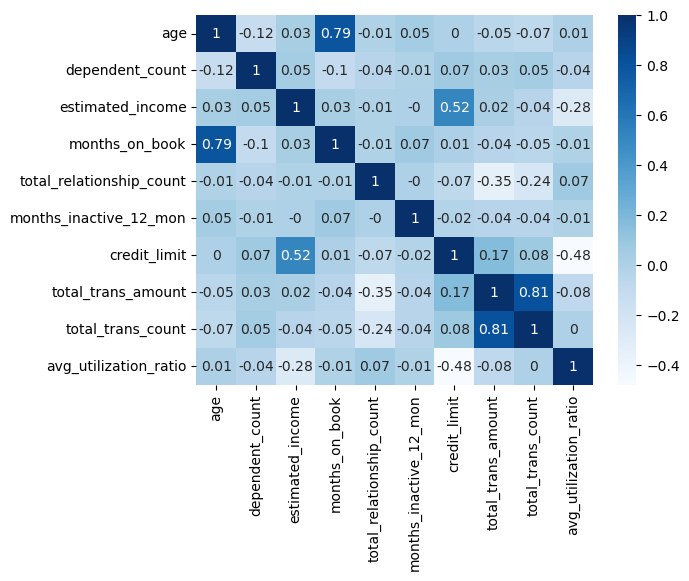

In [7]:
sns.heatmap(round(df.drop('customer_id', axis=1).corr(numeric_only=True), 2), cmap='Blues', annot=True)

Most of the variables present weak correlations with each other, but there are some that we can highlight:
- Age is strongly correlated with how long the person has been a customer(month_on_book)
- Credit limit is positively correlated with the estimated income and negatively correlated with the average utilization ratio
- The total number of transactions is strongly correlated with the total amount transaitioned.

C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\2924513026.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df.drop('customer_id', axis=1).hist(ax = ax)


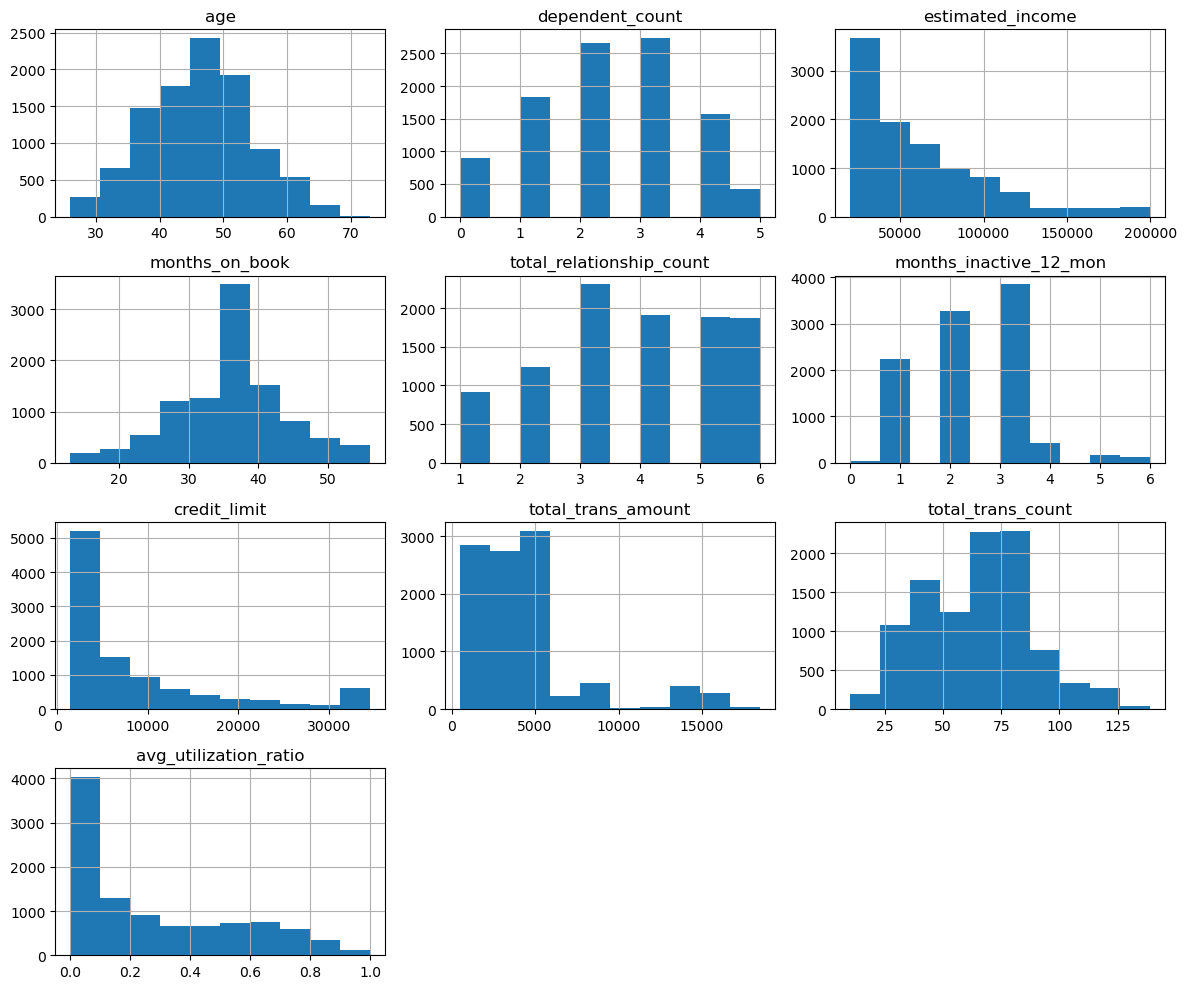

In [8]:
fig, ax = plt.subplots(figsize=(12,10))
df.drop('customer_id', axis=1).hist(ax = ax)
plt.tight_layout()
plt.show()

As we can see that age, months_on_book and total_trans_count are kind of bell curved... we leave them as is.

And estimated_income, credit_limit, total_trans_amount and avg_utilization_ratio are right skewed, so we we will use log1p method to transform them before scaling.

### 2. Feature Engineering and Transformation
Encoding the categorical columns.

- The `gender` column using the map function
- `education_level` also follows a heirarchy thus assigning values like this:
  - `Uneducated: 0`
  - `High School: 1`
  - `College: 2`
  - `Graduate: 3`
  - `Post-Graduate: 4`
  - `Doctorate: 5`
- Unfortunately, we cant do the same for marital_status column, therefore we will use one-hot encoding to create dummy variables

In [9]:
df_modif = df.copy()

C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\863184338.py:8: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_modif.drop('customer_id', axis=1).hist(ax = ax)


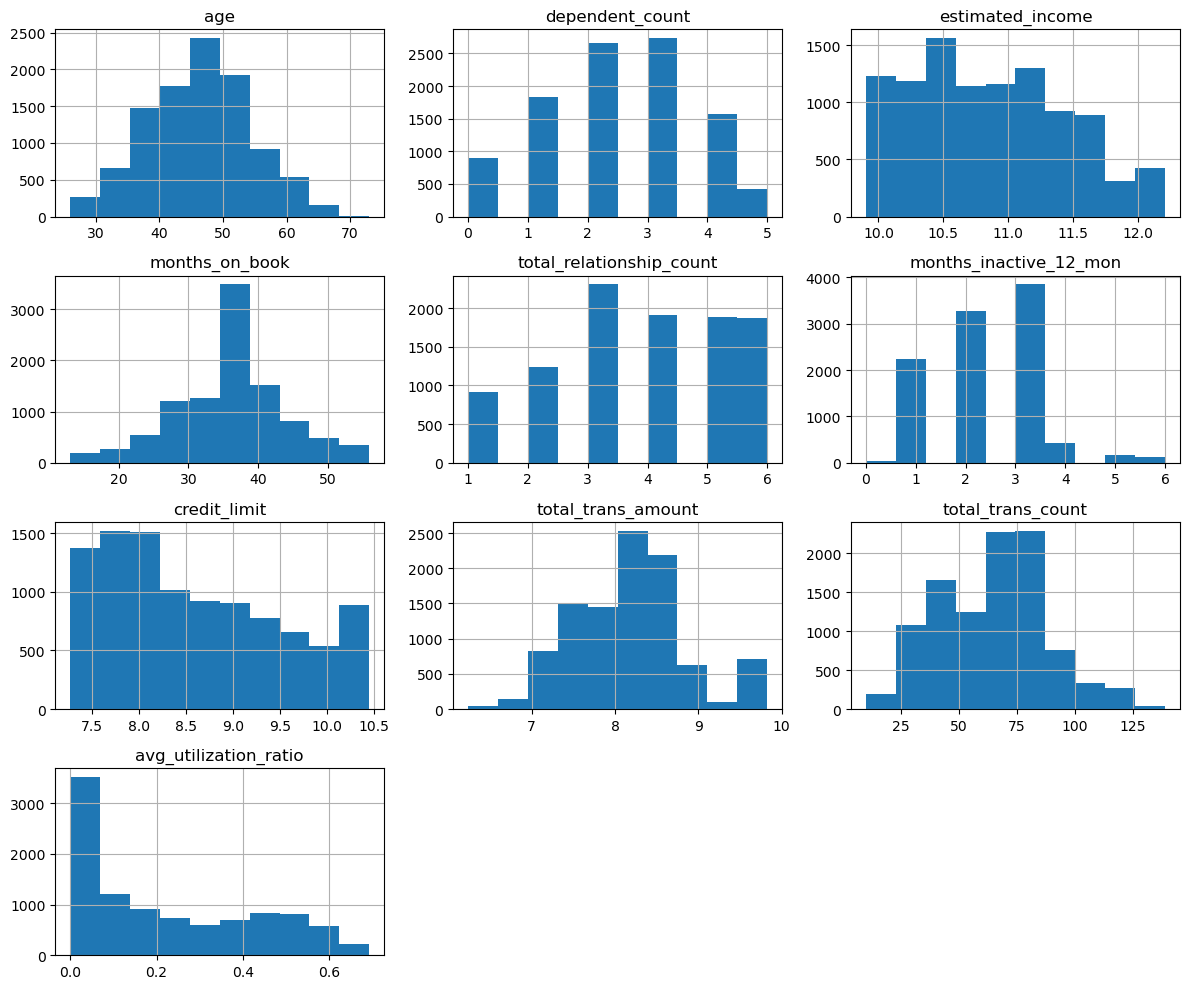

In [10]:
skewed = ['estimated_income', 'credit_limit', 'total_trans_amount', 'avg_utilization_ratio']

for column in skewed:
    df_modif[column] = np.log1p(df[column])

# transformed columns
fig, ax = plt.subplots(figsize=(12,10))
df_modif.drop('customer_id', axis=1).hist(ax = ax)
plt.tight_layout()
plt.show()

We can see from the above two graphs that `avg_utilization_ratio` cant be transformed using a log1p transformer, therefore we switch to power transformer with a yeo-johnson method.

In [11]:
# resetting the value to before the transformed value 
df_modif['avg_utilization_ratio'] = df['avg_utilization_ratio']
avg_ratio = df_modif[['avg_utilization_ratio']]

pt = PowerTransformer(method='yeo-johnson')
avg_ratio_transformed = pt.fit_transform(avg_ratio)


<Axes: ylabel='Count'>

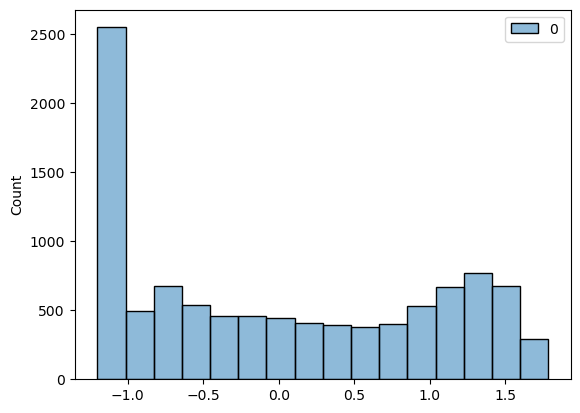

In [12]:
sns.histplot(avg_ratio_transformed)

C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\2616998669.py:5: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df_modif.drop('customer_id', axis=1).hist(ax = ax)


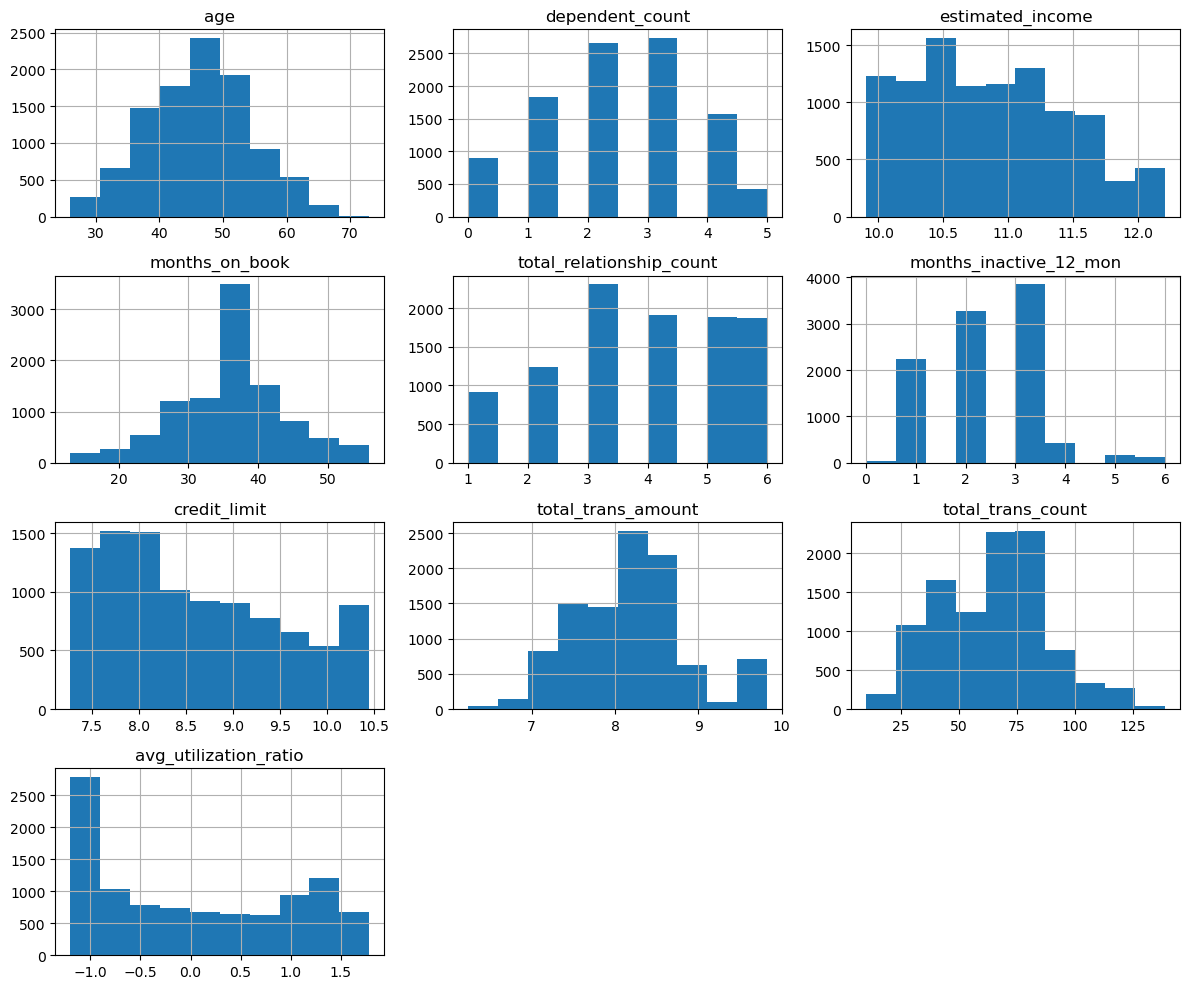

In [13]:
df_modif['avg_utilization_ratio'] = avg_ratio_transformed

# final transformed columns
fig, ax = plt.subplots(figsize=(12,10))
df_modif.drop('customer_id', axis=1).hist(ax = ax)
plt.tight_layout()
plt.show()

In [14]:
# mapping male: 0, and female: 1
df_modif['gender'] = df_modif['gender'].map({'M': 0, 'F':1})

education_map = {
   'Uneducated': 0,
   'High School': 1,
   'College': 2,
   'Graduate': 3,
   'Post-Graduate': 4,
   'Doctorate': 5
}

df_modif['education_level'] = df_modif['education_level'].map(education_map)

df_modif.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,0,3,1,Married,11.141876,39,5,1,9.448727,7.043160,42,-0.768027
1,818770008,49,1,5,3,Single,10.085851,44,6,1,9.018817,7.163947,33,-0.497366
2,713982108,51,0,3,3,Married,11.440366,36,4,1,8.137103,7.543273,20,-1.201678
3,769911858,40,1,4,1,Unknown,10.518700,34,3,4,8.105911,7.066467,20,1.484731
4,709106358,40,0,3,0,Married,11.082158,21,5,1,8.458928,6.705639,28,-1.201678


In [17]:
marital = pd.get_dummies(df_modif['marital_status'], drop_first=True)

df_modif = pd.concat([df_modif, marital], axis=1)
df_modif.drop(['marital_status'], axis=1, inplace=True)

print(df_modif.shape)
df_modif.head()

(10127, 16)


,customer_id,age,gender,dependent_count,education_level,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,Married,Single,Unknown
0,768805383,45,0,3,1,11.141876,39,5,1,9.448727,7.043160,42,-0.768027,True,False,False
1,818770008,49,1,5,3,10.085851,44,6,1,9.018817,7.163947,33,-0.497366,False,True,False
2,713982108,51,0,3,3,11.440366,36,4,1,8.137103,7.543273,20,-1.201678,True,False,False
3,769911858,40,1,4,1,10.518700,34,3,4,8.105911,7.066467,20,1.484731,False,False,True
4,709106358,40,0,3,0,11.082158,21,5,1,8.458928,6.705639,28,-1.201678,True,False,False


In [18]:
# removing customer_id from df_modif

X = df_modif.drop('customer_id', axis=1)

### 3. Scaling the Data

We will be using two types of scalers based on the EDA we did above:
- `StandardScaler`: `age`, `months_on_book`, `estimated_income`, `credit_limit`, `total_trans_amount`, `total_trans_count`
- `MinMaxScaler`: `dependent_count`, `total_relationship_count`, `months_inactive_12_mon`, `education_level`
And we will leave the rest of the columns unscaled as they are either dummy variables, already scaled(`avg_utilization_ratio`) or binary.

In [23]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers = [
        ('bell_and_log', StandardScaler(), ['age', 'months_on_book', 'estimated_income', 'credit_limit', 'total_trans_amount', 'total_trans_count']),
        ('uniform_and_ordinal', MinMaxScaler(), ['dependent_count', 'total_relationship_count', 'months_inactive_12_mon', 'education_level'])
    ],
    remainder='passthrough'
)

X_scaled = preprocessor.fit_transform(X)

### 4. Deciding on Number of Clusters

We start by initialing kmeans with 1 cluster all the way to 10 clusters, then measure the inertia for each number of clusters.
Plot the `inertia` graph to decide how many clusters should be enough.

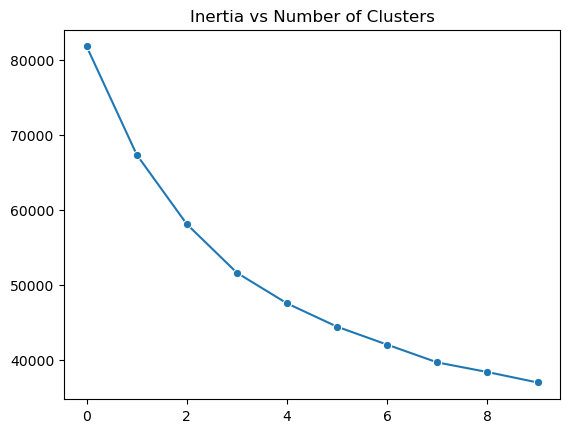

In [24]:
inertias = []

for n in range(1,11):
    kmeans = KMeans(n_clusters=n, random_state=77)
    kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)

sns.lineplot(inertias, marker='o')
plt.title('Inertia vs Number of Clusters')
plt.show()

It looks like the rate of decreasing of inertia slows down between 4 and 6 clusters. but we cannot decide basis on this graph alone, as there is no definite `elbow` to this curve, thus.

To further narrow down on number of clusters we will check for the silhoutte scoure for 4, 5, 6 and 7 clusters, and whichever has the highest score we will finalazing those number of clusters

In [33]:
from sklearn.metrics import silhouette_score

for k in range(2, 9): 
    kmeans = KMeans(n_clusters=k, random_state=77)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    print(f"For K={k}, the Silhouette Score is: {score:.4f}")

For K=2, the Silhouette Score is: 0.1764
For K=3, the Silhouette Score is: 0.1706
For K=4, the Silhouette Score is: 0.1661
For K=5, the Silhouette Score is: 0.1521
For K=6, the Silhouette Score is: 0.1620
For K=7, the Silhouette Score is: 0.1638
For K=8, the Silhouette Score is: 0.1588


There could be some reasons for these low silhouette scores, such as:
1. High dimensionality of our dataset, as we saw earlier some features were strongly correlated to each other, we could tackle this by reducing the dimensionality of our dataset either manually removing those rows with high correlation, or by using PCA.
2. The data on our hand might not be fit for KMeans alone, because of the ordinal categorical variables. In that case we would look towards other algorithms.

For now we will move forward with PCA and check if we can reducae the dimensionality of our trained data.

### PCA

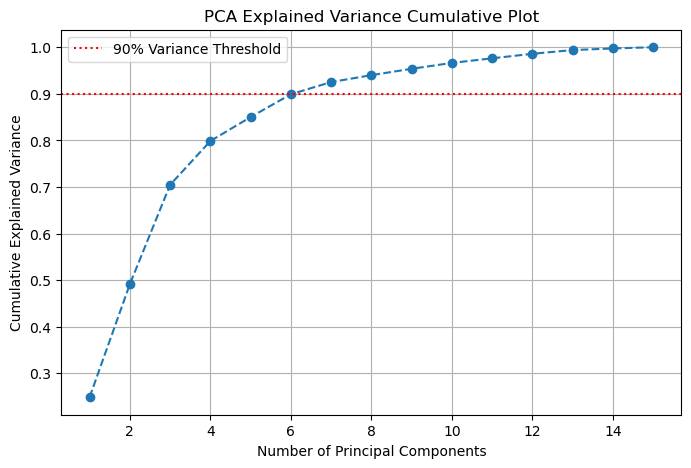

In [30]:
from sklearn.decomposition import PCA

# Initialize PCA without limiting components to see the full picture
pca_full = PCA(random_state=77)
pca_full.fit(X_scaled)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Plot the Scree Plot / Elbow curve for PCA
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title('PCA Explained Variance Cumulative Plot')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

From the above graph, we have decided to keep the n_components as 6, as it crosses our 90% variance threshold

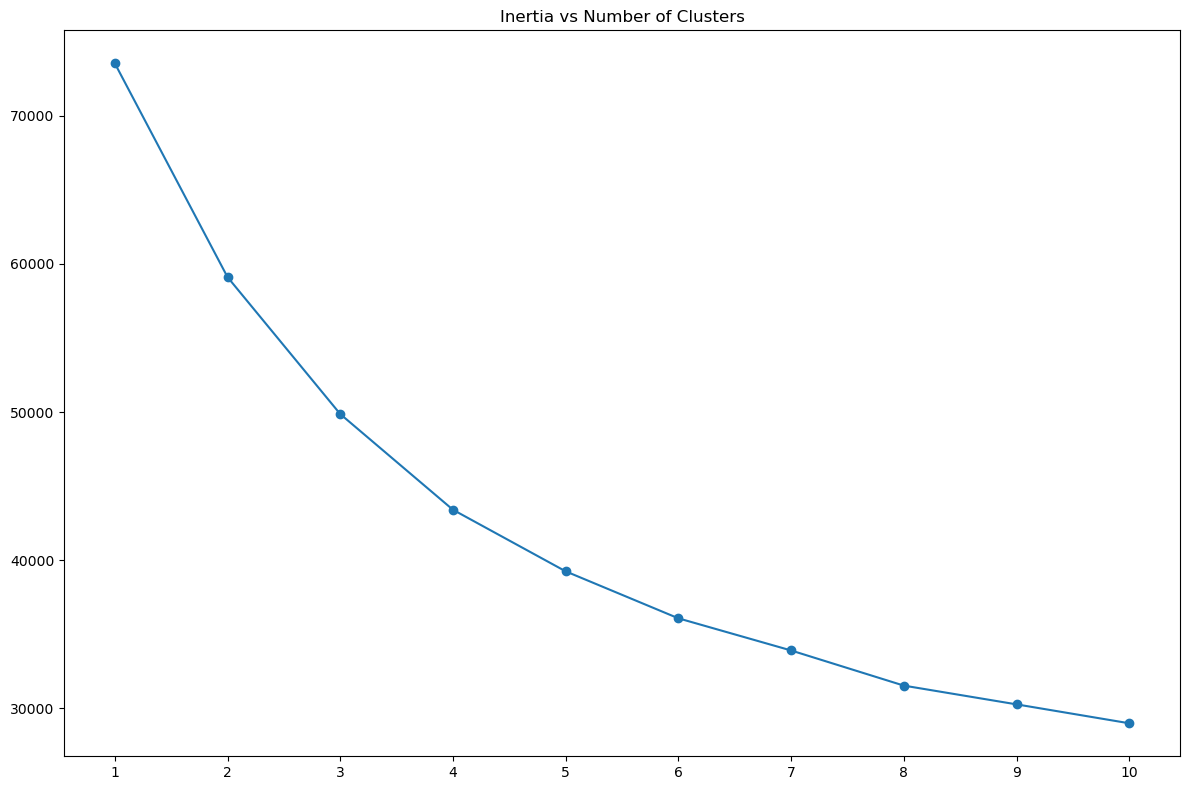

In [32]:
pca = PCA(n_components=6, random_state=77)
X_pca = pca.fit_transform(X_scaled)

inertias = []

for n in range(1,11):
    kmeans = KMeans(n_clusters=n, random_state=77)
    kmeans.fit_predict(X_pca)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(12, 8))
plt.plot(range(1, 11), inertias, marker='o')
plt.xticks(ticks=range(1, 11), labels=range(1, 11))
plt.title('Inertia vs Number of Clusters')

plt.tight_layout()
plt.show()

Again we go to check the silhoutte score of clustersd 5,6,7,8

In [35]:
for k in [5,6,7,8]:
    kmeans = KMeans(n_clusters=k, random_state=77)
    cluster_labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, cluster_labels)
    print(f"For K={k}, the Silhouette Score is: {score:.4f}")

For K=5, the Silhouette Score is: 0.1876
For K=6, the Silhouette Score is: 0.1980
For K=7, the Silhouette Score is: 0.1945
For K=8, the Silhouette Score is: 0.1922


###  Picking the Right Number of Clusters

#### 4.1. Why We Picked 6 Clusters using 6 PCA Components

After using a `ColumnTransformer` to properly fix the skewed data and put all features on a fair playing field, the true silhouette score sat around 0.17. This low score tells us that our users don't live in perfectly separated, isolated bubbles; instead, they form a continuous, dense cloud where behaviors smoothly blend into one another. 

To clean up multi-dimensional noise, I ran Principal Component Analysis (PCA). The variance plot showed that **6 components** capture exactly 90% of the dataset's core information. When I re-ran K-Means on these 6 components, the silhouette score peaked at **0.1980 at K=6**. Since the best mathematical separation (K=6) matches the natural dimensions of the data (6 components), choosing 6 clusters is the most stable and justifiable choice for this project.

#### 4.2. Future Improvements: The DBSCAN Route
Because our max silhouette score is around 0.20, we have proof that our data forms one giant, continuous shape rather than perfect little spheres. K-Means is a rigid algorithm—it forces straight line boundaries to cut the data into equal-sized pizza slices, even if the data doesn't want to be cut that way. 

A great next step for this project would be trying **DBSCAN** (Density-Based Spatial Clustering). Unlike K-Means, DBSCAN doesn't look for circles and it doesn't care about averages. It works like a heat map: it looks for crowded neighborhoods of data points and groups them together, no matter what weird shape they form. Additionally, it automatically flags lonely, scattered data points as "noise" instead of forcing them into a cluster they don't belong in. If we wanted a purely natural grouping rather than strict business boundaries, a density-based model like DBSCAN would be the ultimate upgrade.

With this, we move on to doing our analysis using 6 clusters

### 5. Analyzing the Results

In [38]:
model = KMeans(n_clusters=6)
y = model.fit_predict(X_pca)

y

array([0, 3, 3, ..., 4, 4, 2], shape=(10127,), dtype=int32)

Since the cluster values range from 0 to 5, hen merging with the original dataset, we will set the cluster value as `y+1`

In [41]:
df['cluster'] = y+1
df.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio,cluster
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061,1
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105,4
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000,4
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760,6
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000,6


In [42]:
df['cluster'].value_counts()

cluster
2    2283
1    2177
5    1583
6    1556
4    1338
3    1190
Name: count, dtype: int64

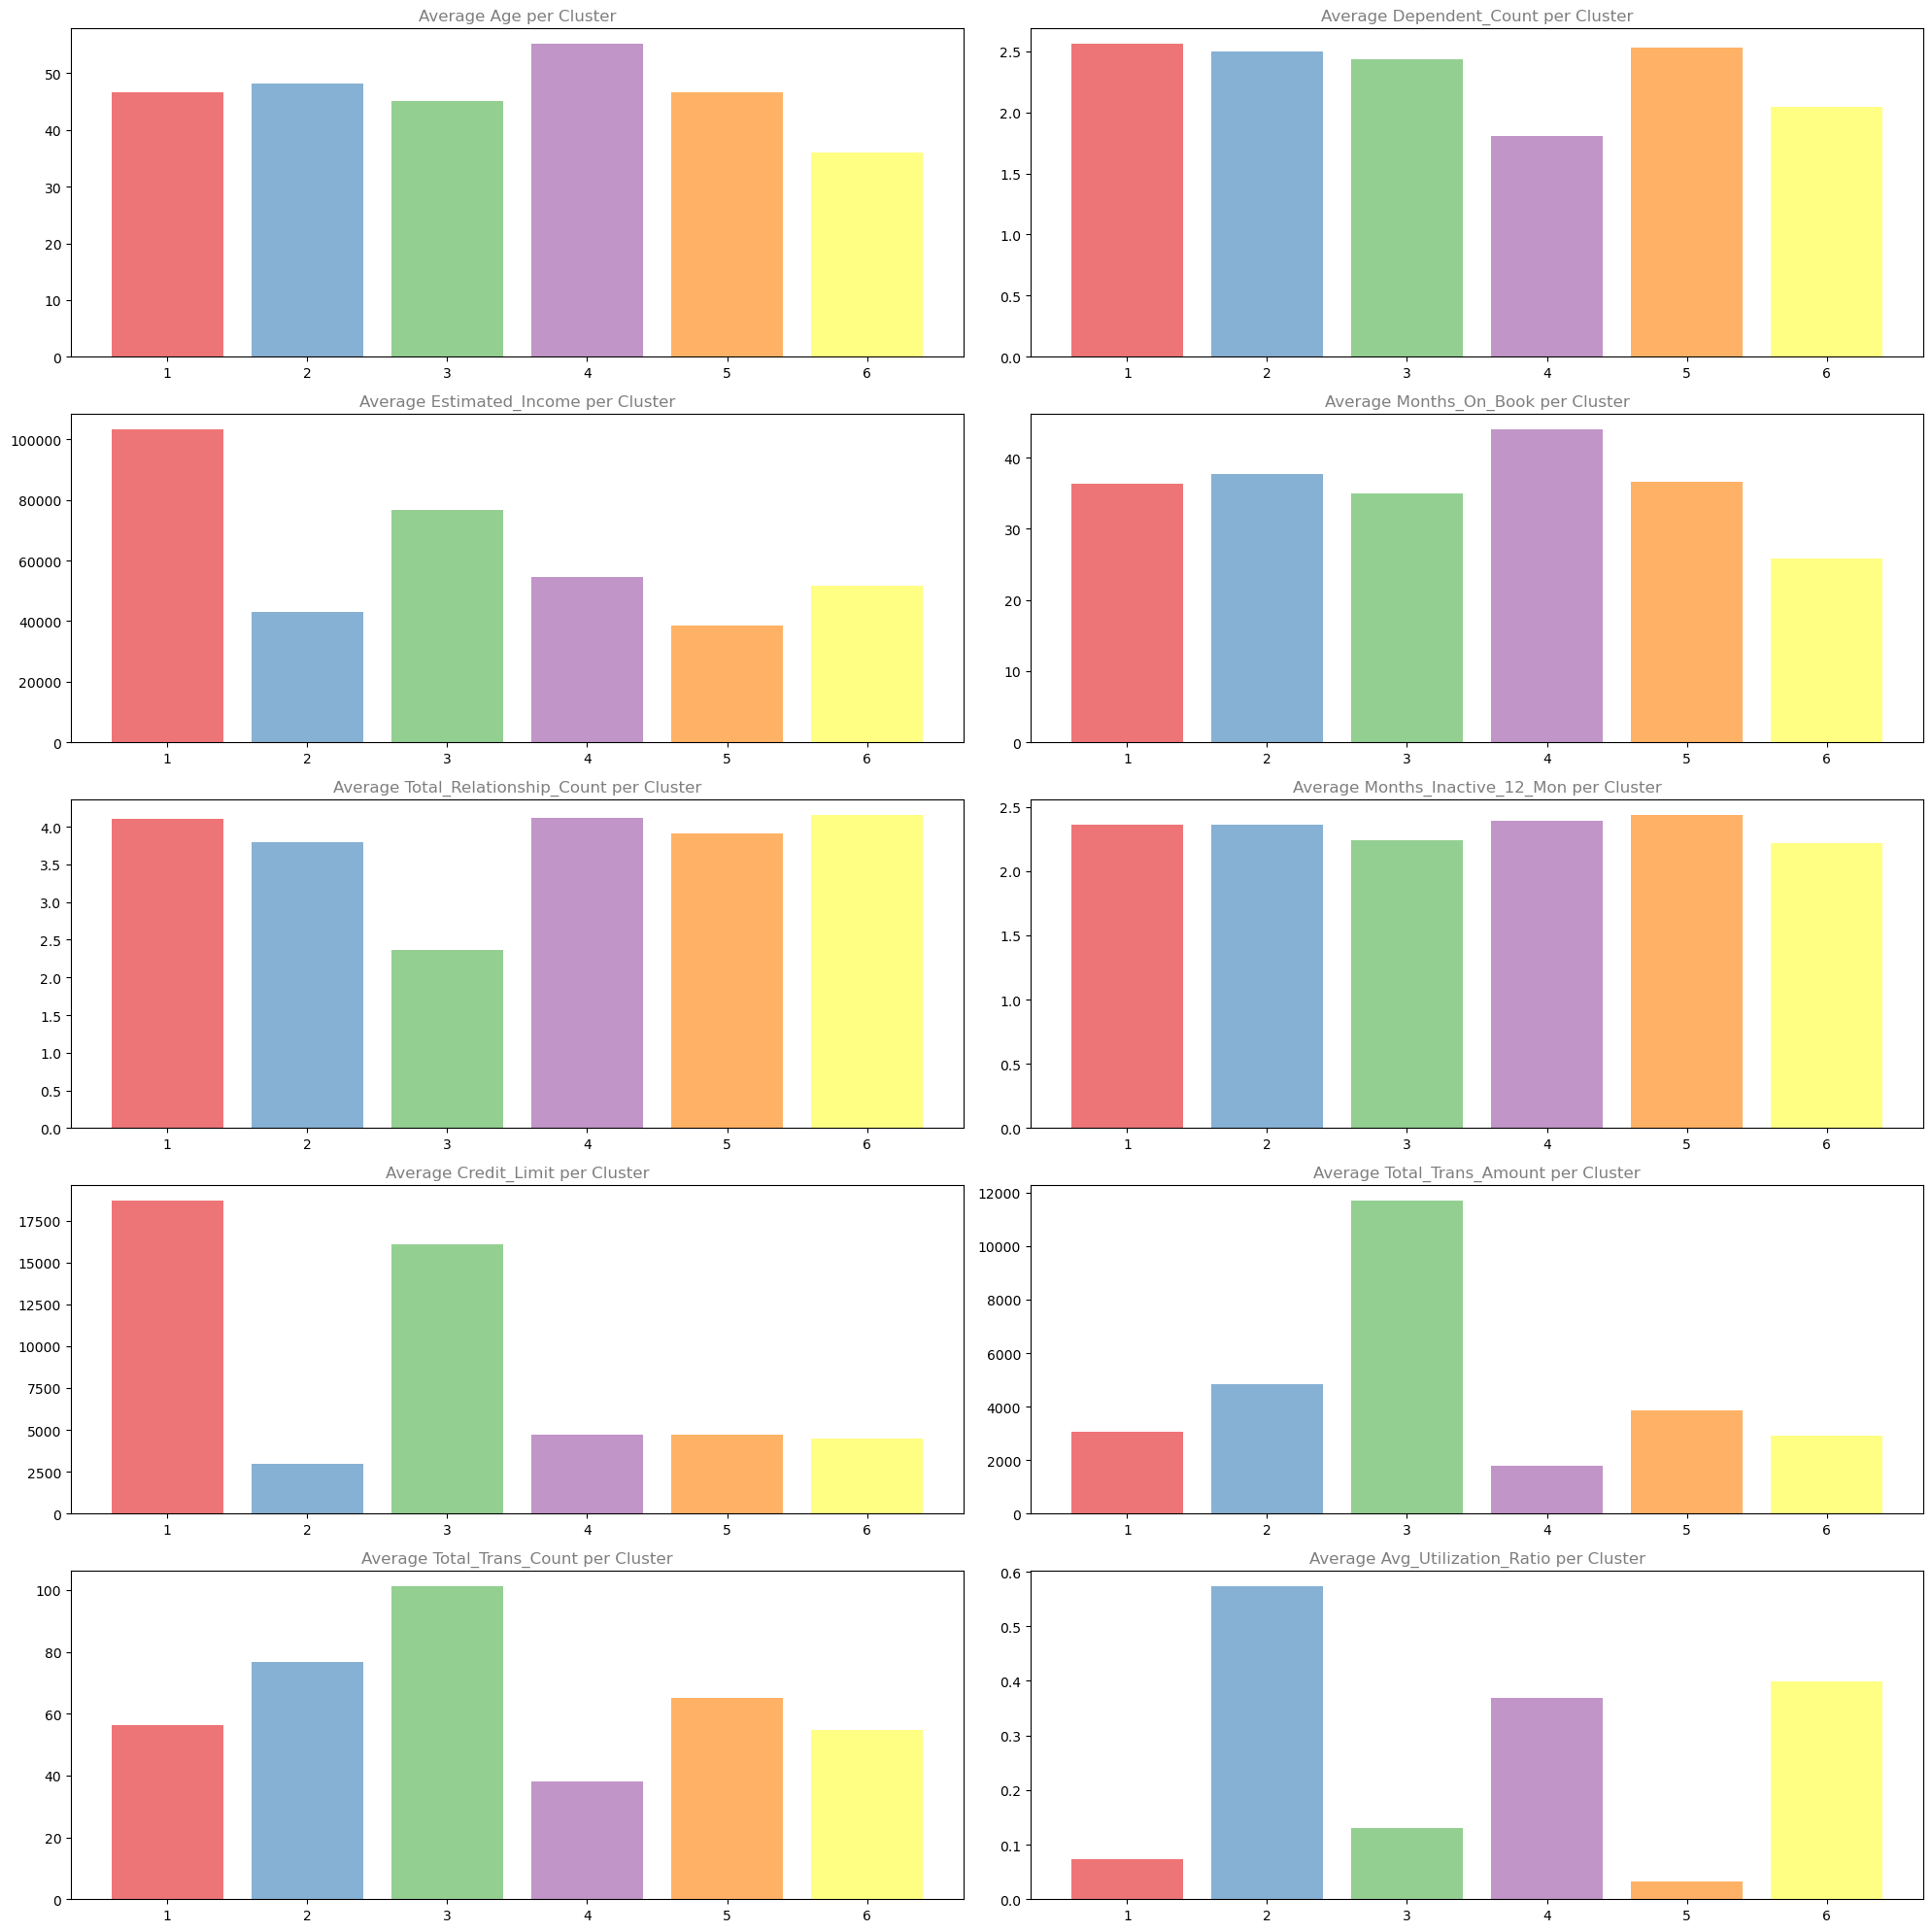

In [47]:
numeric_columns = df.select_dtypes(include=np.number).drop(['customer_id', 'cluster'], axis=1).columns

fig = plt.figure(figsize=(20, 20))
for i, column in enumerate(numeric_columns):
    df_plot = df.groupby('cluster')[column].mean()
    ax = fig.add_subplot(5, 2, i+1)
    ax.bar(df_plot.index, df_plot, color=sns.color_palette('Set1'), alpha=0.6)
    ax.set_title(f'Average {column.title()} per Cluster', alpha=0.5)
    ax.xaxis.grid(False)

plt.tight_layout()
plt.show()

Looking at the above graphs, some standout conclusions are:
- All the clusters have approximately uniform distribution of age, with avg age of cluster 4 being slightly higher, and cluster 6 having the lowest avg age.
- Cluster 1 have the highest avg income.
- Cluster 3 have the least relationship with the bank.
- Cluster 1 and 3 have significantly higher credit limits as compared to other clusters.
- Cluster 3 have the most transactions while 4 have the least.
- Cluster 1 and 5 have very low credit utilization, while cluster 2 have the highest.
- Cluster 3 have the highest total transaction amount.
- Cluster 6 are among the latest customers of the bank, with the lowest months on book.

C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\1459679688.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\1459679688.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
C:\Users\kanis\AppData\Local\Temp\ipykernel_39448\1459679688.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


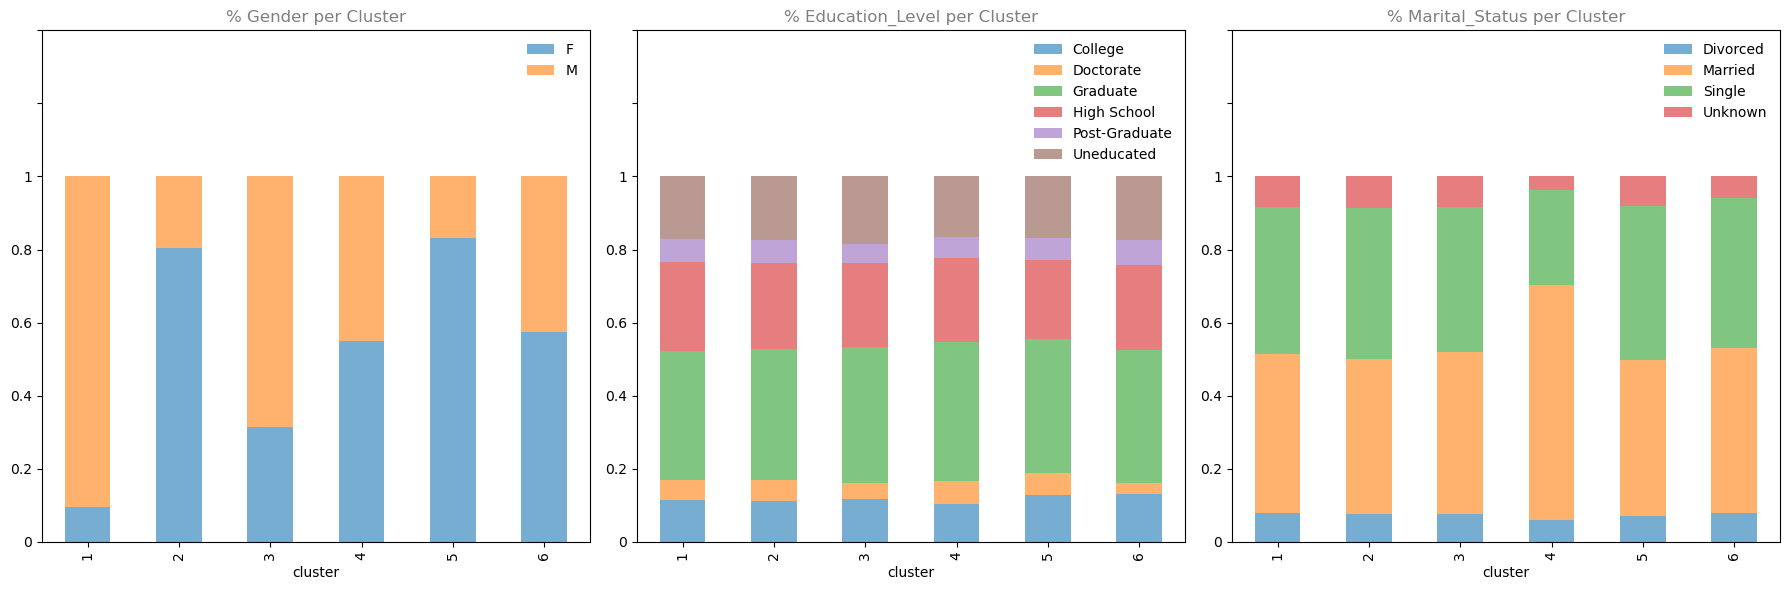

In [48]:
cat_columns = df.select_dtypes(include=['object'])

fig = plt.figure(figsize=(18, 6))
for i, col in enumerate(cat_columns):
    plot_df = pd.crosstab(index=df['cluster'], columns=df[col], values=df[col], aggfunc='size', normalize='index')
    ax = fig.add_subplot(1, 3, i+1)
    plot_df.plot.bar(stacked=True, ax=ax, alpha=0.6)
    ax.set_title(f'% {col.title()} per Cluster', alpha = 0.5)

    ax.set_ylim(0, 1.4)
    ax.legend(frameon=False)
    ax.xaxis.grid(False)

    labels = [0, 0.2, 0.4, 0.6, 0.8, 1]
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

Looking at the graphs of categorical columns, here are some standout conclusions:
- Cluster 1 and 3 mainly comprises of Male customers while Cluster2 and 5 comprise mainly of females.
- The Education level per cluster is uniformly distributed.
- Marital status of customer is also uniformly distributed with cluster 4 having more married customers.

## Conclusion

For the final conclusion I have listed the characteristic of each cluster. And in the end, there is the list of customers with a cluster assigned to each one.

#### Cluster 1:
- **Characteristics**: mostly men, highest income, high credit limit, low transaction count, lower transaction amount, low utilization ratio.

- **insights**: High earning, high credit limit men, who barely use the card. Should be targeted for specific rewards programs to increase utlization

#### Cluster 2:
- **Characteristic**: mostly women, lower income, lowest credit limit, high transaction count, low transaction amount, highest utilization ratio.
  
- **insights**: These users heavily rely on the credit line for daily or routine expenses. But the low income could be a cause of elevated default risk. 

#### Cluster 3:
- **Characteristics**: mostly men (70%), higher income, lowest relationship with bank, higher credit limit, highest transaction count and amount, lower utilization ratio.

- **insights**: These are high income, high limits and highest transaction volume, with good utlization ratio. Retention should be the priority, through loyalty rewards and dedicated custmer service.

#### Cluster 4:
- **Characteristics**: highest age, lowest dependent count, lower income, most relationship with the bank, lower credit limit, lowest transaction count, highest months on book, lowest transaction amount, high utilization ratio, mostly married people.

- **insights**: Predominantly older customers, with the most history with the bank, they are likely loyal. The bank could offer cashback incentives or retirement based products.

#### Cluster 5:
- **Characteristics**: mostly female, lowest income, lower credit limit, high transaction count, normal transaction amount, lowest utilization ratio.

- **insights**: unlike cluster 2, these customers are high disciplined and risk averse. Could offer better limits or better rewards program to increase consumption.

#### Cluster 6:
- **Characteristics**: lowest age, low income, lower credit limit, avg transaction count, normal transaction amount, higher utilization ratio, lowest months on book.

- **insights**: The youngest of the group, with newer accounts, thus lower credit limits. As their account history matures, automated credit limit increase should be offered.

In [49]:
df[['customer_id', 'cluster']]

,customer_id,cluster
0,768805383,1
1,818770008,4
2,713982108,4
3,769911858,6
4,709106358,6
...,...,...
10122,772366833,3
10123,710638233,6
10124,716506083,5
10125,717406983,5
